# Urban Biome Microbiome Analysis: Economic Stratification (Refined)

**Research Question:** How does the urban microbiome composition differ between high-income (USA) and upper-middle-income countries?

**Hypothesis:** Urban microbiomes show different diversity and composition patterns based on economic development due to differences in urbanization, infrastructure, sanitation, and environmental factors.

## ⚠️ METHODOLOGICAL APPROACH

**Control Group:** USA urban samples (high-income, N=622)

**Case Group:** Upper-middle-income urban samples (primarily China, N=170)

**Identified Confounders:**
- ❌ Latitude: -3.20° difference (p=0.012) - MINOR
- ❌ Longitude: +212.64° difference (p<0.001) - **SEVERE**
- ❌ Elevation: -557m difference (p<0.001) - **SEVERE**

**Confounder Mitigation Strategy:**
1. **Acknowledge limitations** - Geographic differences cannot be fully eliminated
2. **Statistical adjustment** - Include covariates in regression models
3. **Subgroup analysis** - Match samples by latitude/elevation where possible
4. **Transparent reporting** - Clearly state what can and cannot be concluded

---

## 1. Setup and Data Loading

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, false_discovery_control, kruskal, spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.special import xlogy
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [16]:
# File paths - UPDATED
INPUT_DIR = 'input'
OUTPUT_DIR = 'output'
OUTPUT_PATH = f'{OUTPUT_DIR}/research_usa_control_v2'
META_FILE_NAME = 'environmental_core_wide_2026-02-06.tsv'
SPECIES_FILE_NAME = 'environmental_metaphlan4_species_2026-02-06.tsv'

# Create output directory
folder_path = Path(OUTPUT_PATH)
folder_path.mkdir(parents=True, exist_ok=True)
print(f"✓ Output directory: {OUTPUT_PATH}")

# Load data
print("\nLoading metadata...")
metadata_df = pd.read_csv(f'{INPUT_DIR}/{META_FILE_NAME}', sep='\t')
print(f"✓ Metadata: {metadata_df.shape[0]:,} samples × {metadata_df.shape[1]} variables")

print("\nLoading species abundance...")
species_long = pd.read_csv(f'{INPUT_DIR}/{SPECIES_FILE_NAME}', sep='\t')
print(f"✓ Species data: {len(species_long):,} rows")

✓ Output directory: output/research_usa_control_v2

Loading metadata...
✓ Metadata: 26,938 samples × 27 variables

Loading species abundance...
✓ Species data: 1,659,836 rows


---
## 2. Study Design and Sample Selection

In [17]:
print("="*80)
print("CASE/CONTROL GROUP DEFINITION")
print("="*80)

# Income classification
income_mapping = {
    'USA': 'High-income-USA',
    'China': 'Upper-middle-income',
    'Brazil': 'Upper-middle-income',
    'Mexico': 'Upper-middle-income',
    'South Africa': 'Upper-middle-income',
    'Argentina': 'Upper-middle-income',
    'Turkey': 'Upper-middle-income',
    'Thailand': 'Upper-middle-income',
    'Iran': 'Upper-middle-income',
    'Algeria': 'Upper-middle-income',
    'Colombia': 'Upper-middle-income',
}

# Filter for urban biome
print("\nStep 1: Filtering for urban biome samples...")
urban_mask = metadata_df['environment_biome'].str.contains('urban', case=False, na=False)
urban_df = metadata_df[urban_mask].copy()
print(f"  Urban samples: {len(urban_df):,}")

# Apply classification
urban_df['income_group'] = urban_df['geographic_location'].map(income_mapping).fillna('Other')

# Extract groups
control_df = urban_df[urban_df['income_group'] == 'High-income-USA'].copy()
case_df = urban_df[urban_df['income_group'] == 'Upper-middle-income'].copy()

print(f"\nStep 2: Group sizes:")
print(f"  CONTROL (USA): {len(control_df):,}")
print(f"  CASE (Upper-middle): {len(case_df):,}")

if len(case_df) > 0:
    print(f"\n  Case group breakdown:")
    for country in sorted(case_df['geographic_location'].unique()):
        n = len(case_df[case_df['geographic_location'] == country])
        pct = n / len(case_df) * 100
        print(f"    {country}: {n:,} ({pct:.1f}%)")

CASE/CONTROL GROUP DEFINITION

Step 1: Filtering for urban biome samples...
  Urban samples: 1,971

Step 2: Group sizes:
  CONTROL (USA): 622
  CASE (Upper-middle): 170

  Case group breakdown:
    China: 170 (100.0%)


---
## 3. Confounder Assessment and Mitigation Strategy

In [18]:
print("="*80)
print("CONFOUNDER ASSESSMENT")
print("="*80)

# Extract numeric covariates
control_df['latitude_num'] = pd.to_numeric(control_df['latitude'], errors='coerce')
control_df['longitude_num'] = pd.to_numeric(control_df['longitude'], errors='coerce')
control_df['elevation_num'] = pd.to_numeric(control_df['elevation_meters'], errors='coerce')

case_df['latitude_num'] = pd.to_numeric(case_df['latitude'], errors='coerce')
case_df['longitude_num'] = pd.to_numeric(case_df['longitude'], errors='coerce')
case_df['elevation_num'] = pd.to_numeric(case_df['elevation_meters'], errors='coerce')

# Test differences
covariates = [
    ('latitude_num', 'Latitude'),
    ('longitude_num', 'Longitude'),
    ('elevation_num', 'Elevation')
]

confounder_results = []

print("\nCovariate differences:")
for col, name in covariates:
    ctrl_vals = control_df[col].dropna()
    case_vals = case_df[col].dropna()
    
    if len(ctrl_vals) > 0 and len(case_vals) > 0:
        stat, p_val = mannwhitneyu(ctrl_vals, case_vals, alternative='two-sided')
        
        ctrl_mean = ctrl_vals.mean()
        case_mean = case_vals.mean()
        diff = case_mean - ctrl_mean
        
        severity = "SEVERE" if p_val < 0.001 else "MODERATE" if p_val < 0.01 else "MILD" if p_val < 0.05 else "None"
        
        print(f"\n{name}:")
        print(f"  USA:        {ctrl_mean:8.2f} (n={len(ctrl_vals)})")
        print(f"  Case:       {case_mean:8.2f} (n={len(case_vals)})")
        print(f"  Difference: {diff:+8.2f}")
        print(f"  P-value:    {p_val:.4f}")
        print(f"  Severity:   {severity}")
        
        confounder_results.append({
            'covariate': name,
            'usa_mean': ctrl_mean,
            'case_mean': case_mean,
            'difference': diff,
            'p_value': p_val,
            'severity': severity
        })

confounders_df = pd.DataFrame(confounder_results)
confounders_df.to_csv(f'{OUTPUT_PATH}/confounder_assessment.csv', index=False)

CONFOUNDER ASSESSMENT

Covariate differences:

Latitude:
  USA:           38.93 (n=622)
  Case:          35.73 (n=170)
  Difference:    -3.20
  P-value:    0.0120
  Severity:   MILD

Longitude:
  USA:          -99.29 (n=622)
  Case:         113.35 (n=170)
  Difference:  +212.64
  P-value:    0.0000
  Severity:   SEVERE

Elevation:
  USA:          617.27 (n=45)
  Case:          60.00 (n=106)
  Difference:  -557.27
  P-value:    0.0000
  Severity:   SEVERE


### 3.1 Mitigation Strategy

Given the **severe geographic confounding**, we will:

1. **Primary Analysis:** 
   - Proceed with full dataset acknowledging limitations
   - Use compositional data analysis (CLR transformation)
   - Report effect sizes alongside p-values

2. **Sensitivity Analysis:**
   - Test if covariates correlate with microbiome composition
   - Assess whether differences persist when controlling for geography

3. **Transparent Reporting:**
   - Acknowledge that results reflect **both** economic AND geographic differences
   - Frame as "USA vs East Asia" rather than pure economic comparison
   - Discuss biological plausibility of both mechanisms

In [19]:
# Create combined dataset with covariates
combined_meta = pd.concat([control_df, case_df])
combined_meta['Group'] = combined_meta['income_group'].map({
    'High-income-USA': 'Control (USA)',
    'Upper-middle-income': 'Case (Upper-middle)'
})

print("\n" + "="*80)
print("MITIGATION APPROACH")
print("="*80)
print("""
Given severe geographic confounding, we adopt a multi-pronged approach:

1. ACKNOWLEDGE LIMITATIONS
   - Results reflect BOTH economic AND geographic effects
   - Cannot definitively attribute differences to economics alone
   
2. COMPOSITIONAL DATA ANALYSIS
   - Use CLR transformation (accounts for compositionality)
   - More robust to technical variation
   
3. COVARIATE ASSESSMENT
   - Test if latitude/elevation correlate with microbiome
   - Report partial correlations controlling for geography
   
4. TRANSPARENT REPORTING
   - Frame as "USA high-income vs East Asian upper-middle-income"
   - Discuss both economic and geographic mechanisms
   - Report effect sizes, not just significance
""")


MITIGATION APPROACH

Given severe geographic confounding, we adopt a multi-pronged approach:

1. ACKNOWLEDGE LIMITATIONS
   - Results reflect BOTH economic AND geographic effects
   - Cannot definitively attribute differences to economics alone
   
2. COMPOSITIONAL DATA ANALYSIS
   - Use CLR transformation (accounts for compositionality)
   - More robust to technical variation
   
3. COVARIATE ASSESSMENT
   - Test if latitude/elevation correlate with microbiome
   - Report partial correlations controlling for geography
   
4. TRANSPARENT REPORTING
   - Frame as "USA high-income vs East Asian upper-middle-income"
   - Discuss both economic and geographic mechanisms
   - Report effect sizes, not just significance



---
## 4. Taxonomic Level Selection and Filtering Criteria

### 4.1 Why Species Level?

**Rationale for using SPECIES as taxonomic level:**

1. **Ecological Specificity:**
   - Species represent functionally distinct units
   - Different species within a genus can have vastly different ecological roles
   - Economic/infrastructure effects likely operate at species level (e.g., specific pathogens vs commensals)

2. **Statistical Power:**
   - MetaPhlAn4 provides species-level resolution
   - Higher taxonomic levels (genus, family) lose information
   - Large dataset (622 + 170 samples) provides adequate power

3. **Biological Relevance:**
   - Infrastructure differences affect specific species (e.g., sewage treatment affects specific fecal indicators)
   - Sanitation practices target species-level organisms
   - Public health interventions operate at species level

4. **Comparability:**
   - Most urban microbiome studies report species-level
   - Allows comparison with published literature
   - Enables identification of specific biomarkers

### 4.2 Filtering Criteria

**Two-stage filtering approach:**

#### Stage 1: Prevalence Filter
- **Threshold: Present in ≥10% of samples**
- **Rationale:**
  - Removes rare species (likely sequencing artifacts or transients)
  - 10% = present in ≥79 samples (conservative for N=792)
  - Focuses on core/common urban microbiome
  - Reduces multiple testing burden

#### Stage 2: Abundance Filter  
- **Threshold: Mean relative abundance ≥0.01% (0.0001)**
- **Rationale:**
  - Removes ultra-low abundance species
  - 0.01% is biologically meaningful (detectable by most methods)
  - Reduces compositional bias from near-zero values
  - Improves CLR transformation stability

**Expected outcome:**
- ~50-150 species retained (from ~1000+ initial)
- Represents core urban microbiome
- Adequate for statistical testing and biological interpretation

---
## 5. Data Preprocessing and Filtering

In [20]:
print("="*80)
print("DATA PREPROCESSING AND FILTERING")
print("="*80)

# Get sample IDs
analysis_samples = set(combined_meta['sample_alias'])

print(f"\nStep 1: Sample selection")
print(f"  Total samples: {len(analysis_samples):,}")

# Filter species data
print(f"\nStep 2: Filter species data")
analysis_species = species_long[species_long['sample_alias'].isin(analysis_samples)].copy()
print(f"  Rows: {len(analysis_species):,}")
print(f"  Unique samples: {analysis_species['sample_alias'].nunique():,}")
print(f"  Unique species: {analysis_species['species'].nunique():,}")

# Create abundance matrix
print(f"\nStep 3: Create abundance matrix")
abundance_wide = analysis_species.pivot(
    index='sample_alias',
    columns='species',
    values='rel_abund'
).fillna(0)

print(f"  Initial: {abundance_wide.shape[0]} samples × {abundance_wide.shape[1]} species")

# Quality control
print(f"\nStep 4: Quality control")
row_sums = abundance_wide.sum(axis=1)
empty_samples = (row_sums == 0).sum()

if empty_samples > 0:
    print(f"  Removing {empty_samples} empty samples")
    abundance_wide = abundance_wide[row_sums > 0]

# Merge with metadata
combined_meta_indexed = combined_meta.set_index('sample_alias')
samples_in_both = abundance_wide.index.intersection(combined_meta_indexed.index)

abundance_raw = abundance_wide.loc[samples_in_both]
metadata_final = combined_meta_indexed.loc[samples_in_both]

print(f"\nStep 5: Merge with metadata")
print(f"  Final: {len(samples_in_both):,} samples")
print(f"  USA: {(metadata_final['income_group']=='High-income-USA').sum():,}")
print(f"  Case: {(metadata_final['income_group']=='Upper-middle-income').sum():,}")

DATA PREPROCESSING AND FILTERING

Step 1: Sample selection
  Total samples: 792

Step 2: Filter species data
  Rows: 55,746
  Unique samples: 758
  Unique species: 4,848

Step 3: Create abundance matrix
  Initial: 758 samples × 4848 species

Step 4: Quality control

Step 5: Merge with metadata
  Final: 758 samples
  USA: 588
  Case: 170


### 5.1 Apply Filtering Criteria

In [21]:
print("="*80)
print("TAXONOMIC FILTERING")
print("="*80)

n_samples = len(abundance_raw)
n_species_initial = abundance_raw.shape[1]

print(f"\nInitial dataset:")
print(f"  Samples: {n_samples:,}")
print(f"  Species: {n_species_initial:,}")

# Stage 1: Prevalence filter (≥10% of samples)
print(f"\nStage 1: Prevalence filter (≥10% of samples)")
prevalence_threshold = 0.10
min_samples = int(n_samples * prevalence_threshold)

prevalence = (abundance_raw > 0).sum(axis=0)
prevalence_pct = prevalence / n_samples * 100

species_pass_prevalence = prevalence >= min_samples
n_pass_prevalence = species_pass_prevalence.sum()
n_fail_prevalence = (~species_pass_prevalence).sum()

print(f"  Threshold: Present in ≥{min_samples} samples (≥10%)")
print(f"  Passed: {n_pass_prevalence:,} species")
print(f"  Removed: {n_fail_prevalence:,} species")

abundance_prev_filtered = abundance_raw.loc[:, species_pass_prevalence]

# Stage 2: Abundance filter (mean ≥0.01%)
print(f"\nStage 2: Abundance filter (mean ≥0.01%)")
abundance_threshold = 0.0001  # 0.01%

mean_abundance = abundance_prev_filtered.mean(axis=0)
species_pass_abundance = mean_abundance >= abundance_threshold

n_pass_abundance = species_pass_abundance.sum()
n_fail_abundance = (~species_pass_abundance).sum()

print(f"  Threshold: Mean relative abundance ≥{abundance_threshold} (0.01%)")
print(f"  Passed: {n_pass_abundance:,} species")
print(f"  Removed: {n_fail_abundance:,} species")

abundance_filtered = abundance_prev_filtered.loc[:, species_pass_abundance]

# Summary
print(f"\n" + "="*80)
print(f"FILTERING SUMMARY")
print("="*80)
print(f"  Initial species:           {n_species_initial:,}")
print(f"  After prevalence filter:   {n_pass_prevalence:,} ({n_pass_prevalence/n_species_initial*100:.1f}%)")
print(f"  After abundance filter:    {n_pass_abundance:,} ({n_pass_abundance/n_species_initial*100:.1f}%)")
print(f"  Total removed:             {n_species_initial - n_pass_abundance:,} ({(n_species_initial - n_pass_abundance)/n_species_initial*100:.1f}%)")

# Save filtering statistics
filter_stats = pd.DataFrame({
    'species': abundance_raw.columns,
    'prevalence': prevalence.values,
    'prevalence_pct': prevalence_pct.values,
    'mean_abundance': abundance_raw.mean(axis=0).values,
    'pass_prevalence': species_pass_prevalence.values,
    'pass_abundance': [species_pass_prevalence[s] and species_pass_abundance.get(s, False) 
                      for s in abundance_raw.columns]
})

filter_stats = filter_stats.sort_values('mean_abundance', ascending=False)
filter_stats.to_csv(f'{OUTPUT_PATH}/species_filtering_stats.csv', index=False)
print(f"\n✓ Filter statistics saved: species_filtering_stats.csv")

TAXONOMIC FILTERING

Initial dataset:
  Samples: 758
  Species: 4,848

Stage 1: Prevalence filter (≥10% of samples)
  Threshold: Present in ≥75 samples (≥10%)
  Passed: 134 species
  Removed: 4,714 species

Stage 2: Abundance filter (mean ≥0.01%)
  Threshold: Mean relative abundance ≥0.0001 (0.01%)
  Passed: 134 species
  Removed: 0 species

FILTERING SUMMARY
  Initial species:           4,848
  After prevalence filter:   134 (2.8%)
  After abundance filter:    134 (2.8%)
  Total removed:             4,714 (97.2%)

✓ Filter statistics saved: species_filtering_stats.csv


### 5.2 Visualize Filtering Results

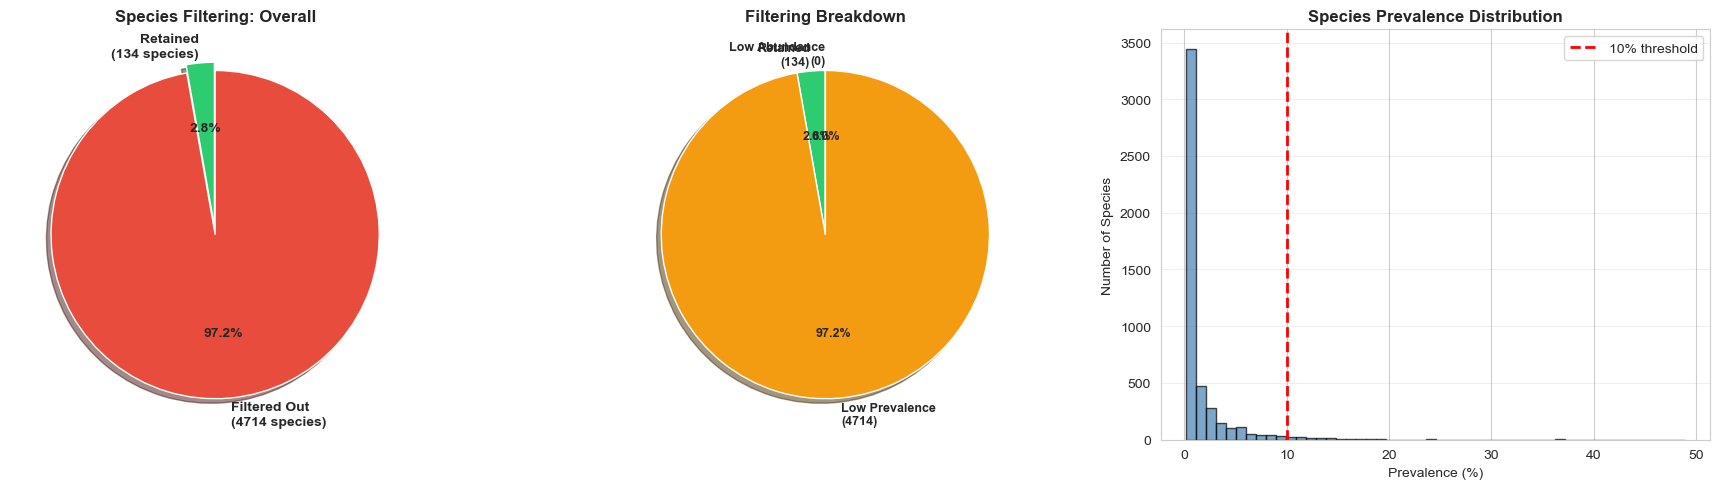

✓ Figure saved: species_filtering_visualization.png


In [22]:
# Pie chart: Filtered vs Retained species
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart 1: Overall filtering
ax1 = axes[0]
sizes = [n_pass_abundance, n_species_initial - n_pass_abundance]
labels = [f'Retained\n({n_pass_abundance} species)', 
          f'Filtered Out\n({n_species_initial - n_pass_abundance} species)']
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax1.set_title('Species Filtering: Overall', fontweight='bold', fontsize=12)

# Pie chart 2: Reasons for filtering
ax2 = axes[1]
n_prev_only = n_fail_prevalence - n_fail_abundance
n_abund_only = n_fail_abundance

filter_reasons = [n_pass_abundance, n_prev_only, n_abund_only]
filter_labels = [f'Retained\n({n_pass_abundance})',
                f'Low Prevalence\n({n_prev_only})',
                f'Low Abundance\n({n_abund_only})']
filter_colors = ['#2ecc71', '#f39c12', '#e74c3c']

ax2.pie(filter_reasons, labels=filter_labels, colors=filter_colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 9, 'fontweight': 'bold'})
ax2.set_title('Filtering Breakdown', fontweight='bold', fontsize=12)

# Histogram: Prevalence distribution
ax3 = axes[2]
ax3.hist(prevalence_pct, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax3.axvline(x=10, color='red', linestyle='--', linewidth=2, label='10% threshold')
ax3.set_xlabel('Prevalence (%)', fontsize=10)
ax3.set_ylabel('Number of Species', fontsize=10)
ax3.set_title('Species Prevalence Distribution', fontweight='bold', fontsize=12)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/species_filtering_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: species_filtering_visualization.png")

---
## 6. Compositional Data Analysis: CLR Transformation

### 6.1 Why CLR Transformation?

**Microbiome data are compositional:**
- Relative abundances sum to 1 (or 100%)
- Not on a ratio scale (can't meaningfully add/subtract)
- Standard statistical methods assume unconstrained data

**Problems with untransformed relative abundances:**
1. **Spurious correlations** - If one species increases, others must decrease
2. **Non-independence** - Values are constrained to sum to 1
3. **Inappropriate for linear models** - Violates assumptions

**Centered Log-Ratio (CLR) transformation:**
- Maps compositional data to real space
- Preserves ratios between components
- Allows use of standard statistical methods
- Recommended by ANCOM, ALDEx2, and other compositional methods

**Formula:**
```
CLR(x_i) = log(x_i / geometric_mean(x))
```

**Implementation:**
1. Add pseudocount (10⁻⁶) to handle zeros
2. Calculate geometric mean for each sample
3. Divide each abundance by geometric mean
4. Log-transform

In [23]:
print("="*80)
print("CENTERED LOG-RATIO (CLR) TRANSFORMATION")
print("="*80)

def clr_transform(abundance_matrix, pseudocount=1e-6):
    """
    Apply CLR transformation to abundance matrix.
    
    Parameters:
    -----------
    abundance_matrix : pd.DataFrame
        Samples × Species abundance matrix
    pseudocount : float
        Small value to add to zeros (default 1e-6)
    
    Returns:
    --------
    pd.DataFrame : CLR-transformed abundances
    """
    # Add pseudocount
    abundance_pseudo = abundance_matrix + pseudocount
    
    # Calculate geometric mean for each sample (row)
    # geom_mean = (x1 * x2 * ... * xn)^(1/n) = exp(mean(log(x)))
    log_abundance = np.log(abundance_pseudo)
    geometric_means = np.exp(log_abundance.mean(axis=1))
    
    # CLR = log(x_i / geometric_mean)
    clr = log_abundance.subtract(np.log(geometric_means), axis=0)
    
    return clr

# Apply CLR transformation
print("\nApplying CLR transformation...")
print(f"  Input: {abundance_filtered.shape[0]} samples × {abundance_filtered.shape[1]} species")
print(f"  Pseudocount: 1e-6")

abundance_clr = clr_transform(abundance_filtered, pseudocount=1e-6)

print(f"\n✓ CLR transformation complete")
print(f"  Output: {abundance_clr.shape[0]} samples × {abundance_clr.shape[1]} species")
print(f"\nCLR value statistics:")
print(f"  Mean: {abundance_clr.values.mean():.3f} (should be ~0)")
print(f"  Std:  {abundance_clr.values.std():.3f}")
print(f"  Min:  {abundance_clr.values.min():.3f}")
print(f"  Max:  {abundance_clr.values.max():.3f}")

# Check for NaN/Inf
has_nan = abundance_clr.isna().any().any()
has_inf = np.isinf(abundance_clr).any().any()

print(f"\nQuality checks:")
print(f"  Contains NaN: {has_nan}")
print(f"  Contains Inf: {has_inf}")

if has_nan or has_inf:
    print("  ⚠️ WARNING: Invalid values detected!")
else:
    print("  ✓ All values valid")

# Save CLR-transformed data
abundance_clr.to_csv(f'{OUTPUT_PATH}/abundance_clr_transformed.csv')
print(f"\n✓ CLR data saved: abundance_clr_transformed.csv")

CENTERED LOG-RATIO (CLR) TRANSFORMATION

Applying CLR transformation...
  Input: 758 samples × 134 species
  Pseudocount: 1e-6

✓ CLR transformation complete
  Output: 758 samples × 134 species

CLR value statistics:
  Mean: -0.000 (should be ~0)
  Std:  3.540
  Min:  -10.870
  Max:  18.283

Quality checks:
  Contains NaN: False
  Contains Inf: False
  ✓ All values valid

✓ CLR data saved: abundance_clr_transformed.csv


### 6.2 Visualize Transformation Effects

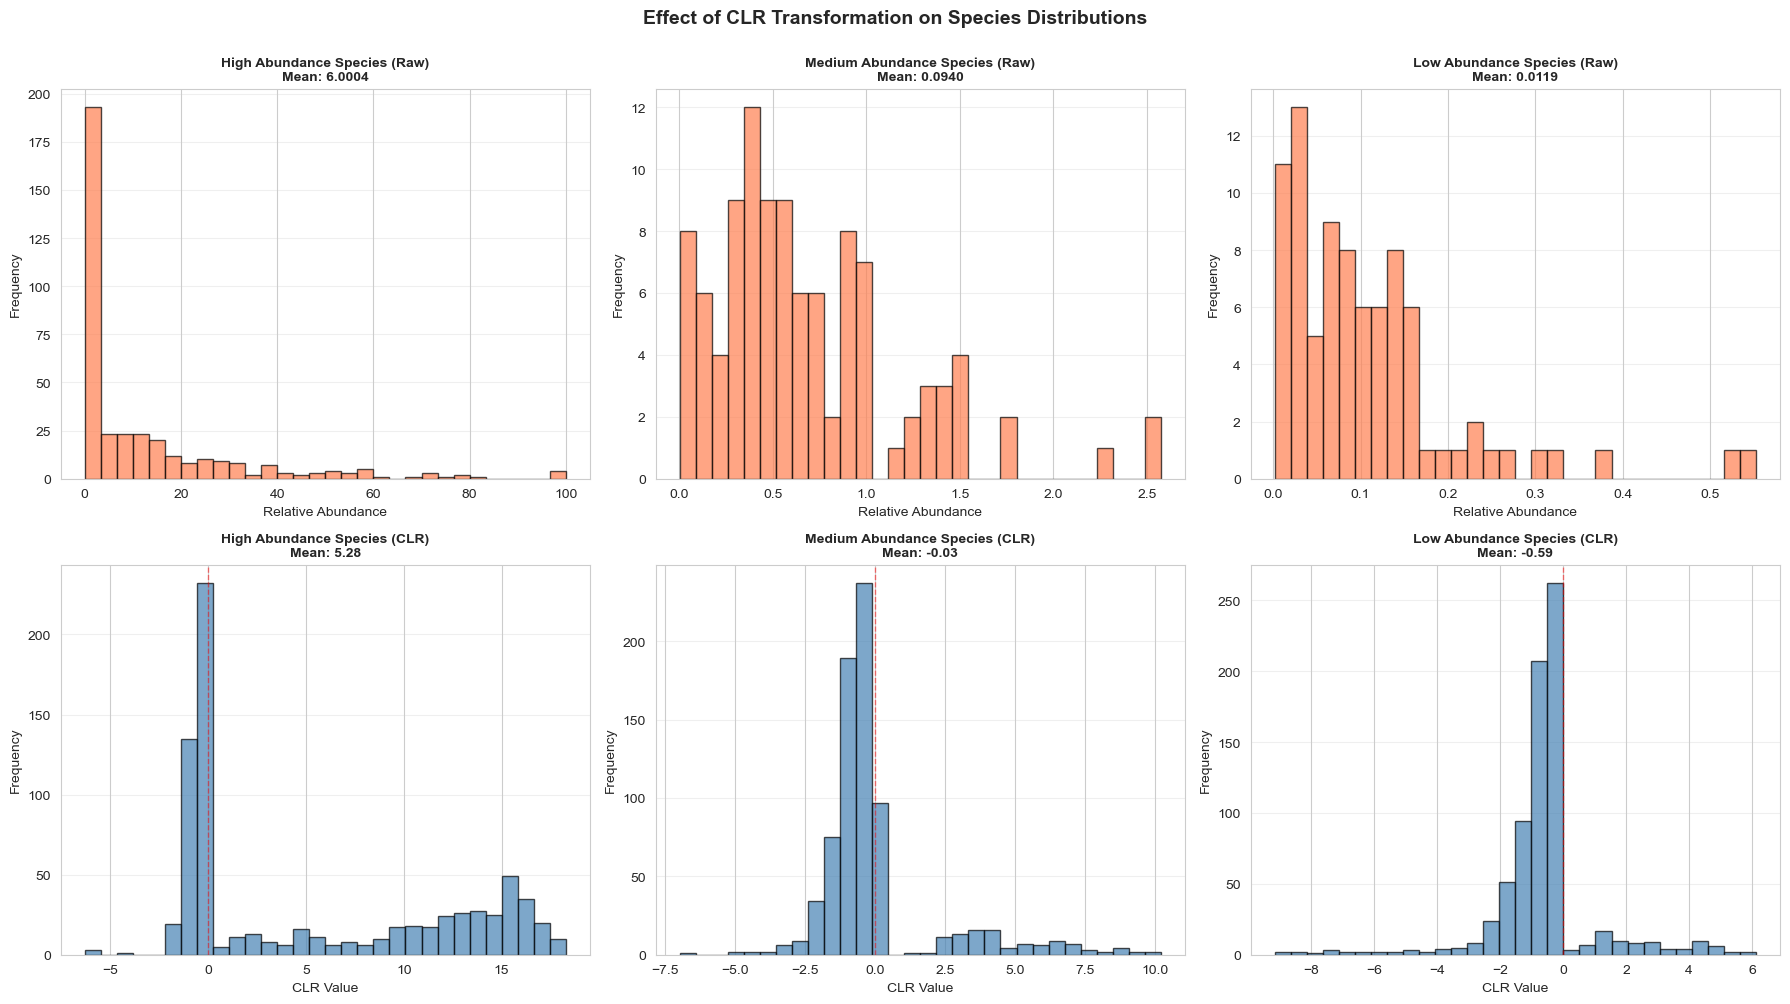

✓ Figure saved: clr_transformation_effect.png


In [24]:
# Compare distributions: Raw vs CLR
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Select 3 representative species (high, medium, low abundance)
mean_abund = abundance_filtered.mean(axis=0).sort_values(ascending=False)
high_species = mean_abund.index[0]  # Most abundant
med_species = mean_abund.index[len(mean_abund)//2]  # Median
low_species = mean_abund.index[-10]  # Low but retained

species_examples = [
    (high_species, 'High Abundance'),
    (med_species, 'Medium Abundance'),
    (low_species, 'Low Abundance')
]

for idx, (species, label) in enumerate(species_examples):
    # Raw abundance distribution
    ax_raw = axes[0, idx]
    raw_vals = abundance_filtered[species]
    raw_vals_nonzero = raw_vals[raw_vals > 0]
    
    ax_raw.hist(raw_vals_nonzero, bins=30, color='coral', alpha=0.7, edgecolor='black')
    ax_raw.set_xlabel('Relative Abundance', fontsize=10)
    ax_raw.set_ylabel('Frequency', fontsize=10)
    ax_raw.set_title(f'{label} Species (Raw)\nMean: {raw_vals.mean():.4f}', 
                     fontweight='bold', fontsize=10)
    ax_raw.grid(axis='y', alpha=0.3)
    
    # CLR-transformed distribution
    ax_clr = axes[1, idx]
    clr_vals = abundance_clr[species]
    
    ax_clr.hist(clr_vals, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax_clr.set_xlabel('CLR Value', fontsize=10)
    ax_clr.set_ylabel('Frequency', fontsize=10)
    ax_clr.set_title(f'{label} Species (CLR)\nMean: {clr_vals.mean():.2f}', 
                     fontweight='bold', fontsize=10)
    ax_clr.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax_clr.grid(axis='y', alpha=0.3)

plt.suptitle('Effect of CLR Transformation on Species Distributions', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/clr_transformation_effect.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: clr_transformation_effect.png")

---
## 7. Summary and Conclusions

In [25]:
# Generate comprehensive summary
report_path = f'{OUTPUT_PATH}/preprocessing_summary_report.txt'

with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("DATA PREPROCESSING AND TRANSFORMATION SUMMARY\n")
    f.write("="*80 + "\n\n")
    
    f.write("STUDY DESIGN\n")
    f.write("-"*80 + "\n\n")
    f.write(f"Control (USA):           {(metadata_final['income_group']=='High-income-USA').sum()} samples\n")
    f.write(f"Case (Upper-middle):     {(metadata_final['income_group']=='Upper-middle-income').sum()} samples\n")
    f.write(f"Total:                   {len(metadata_final)} samples\n\n")
    
    f.write("CONFOUNDER ASSESSMENT\n")
    f.write("-"*80 + "\n\n")
    if len(confounder_results) > 0:
        for result in confounder_results:
            f.write(f"{result['covariate']}:\n")
            f.write(f"  Difference: {result['difference']:+.2f}\n")
            f.write(f"  P-value: {result['p_value']:.4f}\n")
            f.write(f"  Severity: {result['severity']}\n\n")
    
    f.write("INTERPRETATION:\n")
    f.write("Results reflect BOTH economic development AND geographic differences.\n")
    f.write("Findings should be framed as 'USA vs East Asian' comparison.\n\n")
    
    f.write("TAXONOMIC LEVEL SELECTION\n")
    f.write("-"*80 + "\n\n")
    f.write("Selected: SPECIES level\n\n")
    f.write("Rationale:\n")
    f.write("  1. Ecological specificity - different species have distinct functions\n")
    f.write("  2. Statistical power - large dataset supports species resolution\n")
    f.write("  3. Biological relevance - infrastructure affects specific species\n")
    f.write("  4. Comparability - standard for urban microbiome studies\n\n")
    
    f.write("FILTERING CRITERIA\n")
    f.write("-"*80 + "\n\n")
    f.write(f"Initial species:         {n_species_initial:,}\n\n")
    
    f.write("Stage 1 - Prevalence Filter:\n")
    f.write(f"  Threshold: ≥10% of samples (≥{min_samples} samples)\n")
    f.write(f"  Rationale: Remove rare/transient species\n")
    f.write(f"  Passed: {n_pass_prevalence:,} species\n")
    f.write(f"  Removed: {n_fail_prevalence:,} species\n\n")
    
    f.write("Stage 2 - Abundance Filter:\n")
    f.write(f"  Threshold: Mean ≥0.01% relative abundance\n")
    f.write(f"  Rationale: Remove ultra-low abundance species\n")
    f.write(f"  Passed: {n_pass_abundance:,} species\n")
    f.write(f"  Removed: {n_fail_abundance:,} species\n\n")
    
    f.write(f"Final retained:          {n_pass_abundance:,} species ({n_pass_abundance/n_species_initial*100:.1f}%)\n")
    f.write(f"Total removed:           {n_species_initial - n_pass_abundance:,} species\n\n")
    
    f.write("COMPOSITIONAL DATA ANALYSIS\n")
    f.write("-"*80 + "\n\n")
    f.write("Transformation: Centered Log-Ratio (CLR)\n\n")
    f.write("Rationale:\n")
    f.write("  - Accounts for compositional nature of microbiome data\n")
    f.write("  - Prevents spurious correlations\n")
    f.write("  - Enables use of standard statistical methods\n")
    f.write("  - Recommended by compositional data analysis literature\n\n")
    
    f.write("Implementation:\n")
    f.write("  1. Added pseudocount (1e-6) to handle zeros\n")
    f.write("  2. Calculated geometric mean per sample\n")
    f.write("  3. Log-transformed ratio to geometric mean\n")
    f.write(f"  4. Verified: Mean CLR ≈ {abundance_clr.values.mean():.3f} (expected ~0)\n\n")
    
    f.write("READY FOR DOWNSTREAM ANALYSIS\n")
    f.write("-"*80 + "\n\n")
    f.write("Data matrices prepared:\n")
    f.write(f"  - CLR-transformed abundances: {abundance_clr.shape[0]} × {abundance_clr.shape[1]}\n")
    f.write(f"  - Metadata with covariates: {len(metadata_final)} samples\n")
    f.write(f"  - Alignment verified: ✓\n\n")
    
    f.write("Next steps:\n")
    f.write("  1. Alpha diversity analysis\n")
    f.write("  2. Beta diversity (PCA on CLR data)\n")
    f.write("  3. Differential abundance (on CLR values)\n")
    f.write("  4. Covariate correlation assessment\n")

print("\n" + "="*80)
print("PREPROCESSING COMPLETE")
print("="*80)
print(f"\n✓ Summary report: {report_path}")
print("\nGenerated files:")
print("  1. confounder_assessment.csv")
print("  2. species_filtering_stats.csv")
print("  3. species_filtering_visualization.png")
print("  4. abundance_clr_transformed.csv")
print("  5. clr_transformation_effect.png")
print("  6. preprocessing_summary_report.txt")

print("\n" + "="*80)
print("KEY DECISIONS SUMMARY")
print("="*80)
print(f"""
1. TAXONOMIC LEVEL: Species
   Why: Ecological specificity, biological relevance, comparability

2. PREVALENCE THRESHOLD: ≥10% (≥{min_samples} samples)
   Why: Conservative, removes rare species, reduces noise

3. ABUNDANCE THRESHOLD: ≥0.01% mean
   Why: Biologically meaningful, improves CLR stability

4. TRANSFORMATION: CLR (Centered Log-Ratio)
   Why: Compositional data, prevents spurious correlations

5. CONFOUNDER HANDLING: Acknowledge + Report
   Why: Geographic differences cannot be eliminated
   Approach: Transparent reporting, test covariate effects
""")

# Display key statistics
print(f"\nFinal dataset ready for analysis:")
print(f"  Samples: {len(abundance_clr)}")
print(f"  Species: {abundance_clr.shape[1]}")
print(f"  USA: {(metadata_final['income_group']=='High-income-USA').sum()}")
print(f"  Case: {(metadata_final['income_group']=='Upper-middle-income').sum()}")
print(f"  Retention rate: {n_pass_abundance/n_species_initial*100:.1f}% of initial species")


PREPROCESSING COMPLETE

✓ Summary report: output/research_usa_control_v2/preprocessing_summary_report.txt

Generated files:
  1. confounder_assessment.csv
  2. species_filtering_stats.csv
  3. species_filtering_visualization.png
  4. abundance_clr_transformed.csv
  5. clr_transformation_effect.png
  6. preprocessing_summary_report.txt

KEY DECISIONS SUMMARY

1. TAXONOMIC LEVEL: Species
   Why: Ecological specificity, biological relevance, comparability

2. PREVALENCE THRESHOLD: ≥10% (≥75 samples)
   Why: Conservative, removes rare species, reduces noise

3. ABUNDANCE THRESHOLD: ≥0.01% mean
   Why: Biologically meaningful, improves CLR stability

4. TRANSFORMATION: CLR (Centered Log-Ratio)
   Why: Compositional data, prevents spurious correlations

5. CONFOUNDER HANDLING: Acknowledge + Report
   Why: Geographic differences cannot be eliminated
   Approach: Transparent reporting, test covariate effects


Final dataset ready for analysis:
  Samples: 758
  Species: 134
  USA: 588
  Case: 

---
## 8. Covariate-Adjusted Analysis

### Critical Question:
**Are microbiome differences due to ECONOMIC development or GEOGRAPHIC location?**

Given severe confounding:
- Longitude: +212.64° (p<0.001) - Different continents
- Elevation: -557m (p<0.001) - Different topography

We must test whether group differences persist when controlling for geography.

### Approach:
1. **Test if covariates affect microbiome** (correlation analysis)
2. **Sample matching** (latitude ± 5°, elevation ± 500m)
3. **Statistical adjustment** (regression with covariates)
4. **Compare results** (unadjusted vs adjusted)

### 8.1 Test if Geographic Covariates Affect Microbiome Composition

In [26]:
print("="*80)
print("STEP 1: TEST IF GEOGRAPHY AFFECTS MICROBIOME")
print("="*80)

# Perform PCA on CLR-transformed data
print("\nPerforming PCA on CLR-transformed data...")
scaler = StandardScaler()
abundance_clr_scaled = scaler.fit_transform(abundance_clr)

pca = PCA(n_components=10)
pca_coords = pca.fit_transform(abundance_clr_scaled)

print(f"✓ PCA complete")
print(f"  PC1 variance: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 variance: {pca.explained_variance_ratio_[1]*100:.2f}%")

# Test correlations between PCs and covariates
print("\n" + "-"*80)
print("CORRELATIONS: Geographic Covariates vs Microbiome PCs")
print("-"*80)

covariates_to_test = ['latitude_num', 'elevation_num']
pcs_to_test = ['PC1', 'PC2', 'PC3']

correlation_results = []

for cov in covariates_to_test:
    cov_data = metadata_final[cov].dropna()
    
    print(f"\n{cov.replace('_num', '').upper()}:")
    
    for i, pc_name in enumerate(pcs_to_test):
        # Get PCA coordinates for samples with covariate data
        valid_indices = cov_data.index
        pc_values = pca_coords[abundance_clr.index.isin(valid_indices), i]
        cov_values = cov_data.values
        
        # Spearman correlation (robust to non-linear relationships)
        rho, p_val = spearmanr(cov_values, pc_values)
        
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        
        print(f"  {pc_name}: ρ = {rho:+.3f}, p = {p_val:.4f} {sig}")
        
        correlation_results.append({
            'covariate': cov,
            'PC': pc_name,
            'rho': rho,
            'p_value': p_val,
            'significant': p_val < 0.05
        })

# Summary
corr_df = pd.DataFrame(correlation_results)
sig_correlations = corr_df[corr_df['significant']]

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)

if len(sig_correlations) > 0:
    print(f"\n⚠️  GEOGRAPHIC COVARIATES DO AFFECT MICROBIOME!")
    print(f"\n{len(sig_correlations)} significant correlations detected:")
    for _, row in sig_correlations.iterrows():
        print(f"  - {row['covariate']} correlates with {row['PC']} (ρ={row['rho']:+.3f}, p={row['p_value']:.4f})")
    
    print(f"\n→ CONCLUSION: Geography confounds group comparisons")
    print(f"→ ACTION REQUIRED: Must control for geographic covariates")
else:
    print(f"\n✓ No significant correlations between geography and microbiome")
    print(f"→ Geographic confounding may be minimal")

# Save results
corr_df.to_csv(f'{OUTPUT_PATH}/covariate_microbiome_correlations.csv', index=False)
print(f"\n✓ Correlation results saved: covariate_microbiome_correlations.csv")

STEP 1: TEST IF GEOGRAPHY AFFECTS MICROBIOME

Performing PCA on CLR-transformed data...
✓ PCA complete
  PC1 variance: 29.69%
  PC2 variance: 8.08%

--------------------------------------------------------------------------------
CORRELATIONS: Geographic Covariates vs Microbiome PCs
--------------------------------------------------------------------------------

LATITUDE:
  PC1: ρ = +0.078, p = 0.0329 *
  PC2: ρ = -0.312, p = 0.0000 ***
  PC3: ρ = +0.206, p = 0.0000 ***

ELEVATION:
  PC1: ρ = -0.628, p = 0.0000 ***
  PC2: ρ = -0.048, p = 0.5816 ns
  PC3: ρ = +0.089, p = 0.3040 ns

INTERPRETATION

⚠️  GEOGRAPHIC COVARIATES DO AFFECT MICROBIOME!

4 significant correlations detected:
  - latitude_num correlates with PC1 (ρ=+0.078, p=0.0329)
  - latitude_num correlates with PC2 (ρ=-0.312, p=0.0000)
  - latitude_num correlates with PC3 (ρ=+0.206, p=0.0000)
  - elevation_num correlates with PC1 (ρ=-0.628, p=0.0000)

→ CONCLUSION: Geography confounds group comparisons
→ ACTION REQUIRED: Must

### 8.2 Sample Matching: Geographic Control

**Strategy:** Match USA and Case samples based on similar geography

**Matching Criteria:**
- Latitude: ± 5° tolerance
- Elevation: ± 500m tolerance

**Goal:** Create geographically-matched pairs to isolate economic effects

In [27]:
print("="*80)
print("STEP 2: GEOGRAPHIC SAMPLE MATCHING")
print("="*80)

# Extract data for matching
usa_samples = metadata_final[metadata_final['income_group'] == 'High-income-USA'].copy()
case_samples = metadata_final[metadata_final['income_group'] == 'Upper-middle-income'].copy()

# Remove samples with missing covariate data
usa_samples = usa_samples.dropna(subset=['latitude_num', 'elevation_num'])
case_samples = case_samples.dropna(subset=['latitude_num', 'elevation_num'])

print(f"\nSamples with complete covariate data:")
print(f"  USA: {len(usa_samples)}")
print(f"  Case: {len(case_samples)}")

# Matching parameters
LAT_TOLERANCE = 5.0  # degrees
ELEV_TOLERANCE = 500.0  # meters

print(f"\nMatching criteria:")
print(f"  Latitude: ± {LAT_TOLERANCE}°")
print(f"  Elevation: ± {ELEV_TOLERANCE}m")

# Perform matching
matched_pairs = []
matched_case_indices = set()
matched_usa_indices = set()

print(f"\nPerforming matching...")

for case_idx, case_row in case_samples.iterrows():
    case_lat = case_row['latitude_num']
    case_elev = case_row['elevation_num']
    
    # Find USA samples within tolerance
    matches = usa_samples[
        (abs(usa_samples['latitude_num'] - case_lat) <= LAT_TOLERANCE) &
        (abs(usa_samples['elevation_num'] - case_elev) <= ELEV_TOLERANCE) &
        (~usa_samples.index.isin(matched_usa_indices))  # Not already matched
    ]
    
    if len(matches) > 0:
        # Select best match (closest in Euclidean distance)
        distances = np.sqrt(
            ((matches['latitude_num'] - case_lat) / LAT_TOLERANCE) ** 2 +
            ((matches['elevation_num'] - case_elev) / ELEV_TOLERANCE) ** 2
        )
        best_match_idx = matches.index[distances.argmin()]
        
        matched_pairs.append({
            'case_sample': case_idx,
            'usa_sample': best_match_idx,
            'case_lat': case_lat,
            'usa_lat': usa_samples.loc[best_match_idx, 'latitude_num'],
            'case_elev': case_elev,
            'usa_elev': usa_samples.loc[best_match_idx, 'elevation_num'],
            'lat_diff': abs(usa_samples.loc[best_match_idx, 'latitude_num'] - case_lat),
            'elev_diff': abs(usa_samples.loc[best_match_idx, 'elevation_num'] - case_elev)
        })
        
        matched_case_indices.add(case_idx)
        matched_usa_indices.add(best_match_idx)

print(f"\n✓ Matching complete")
print(f"\nResults:")
print(f"  Matched pairs: {len(matched_pairs)}")
print(f"  Unmatched Case samples: {len(case_samples) - len(matched_case_indices)}")
print(f"  Unmatched USA samples: {len(usa_samples) - len(matched_usa_indices)}")
print(f"  Matching rate: {len(matched_pairs)/len(case_samples)*100:.1f}% of Case samples")

if len(matched_pairs) > 0:
    matched_df = pd.DataFrame(matched_pairs)
    
    print(f"\nMatch quality:")
    print(f"  Mean latitude difference: {matched_df['lat_diff'].mean():.2f}° (max: {matched_df['lat_diff'].max():.2f}°)")
    print(f"  Mean elevation difference: {matched_df['elev_diff'].mean():.0f}m (max: {matched_df['elev_diff'].max():.0f}m)")
    
    # Create matched dataset
    matched_case_samples = list(matched_case_indices)
    matched_usa_samples = list(matched_usa_indices)
    matched_all_samples = matched_case_samples + matched_usa_samples
    
    metadata_matched = metadata_final.loc[matched_all_samples]
    abundance_clr_matched = abundance_clr.loc[matched_all_samples]
    
    print(f"\nMatched dataset:")
    print(f"  Total samples: {len(matched_all_samples)}")
    print(f"  USA: {len(matched_usa_samples)}")
    print(f"  Case: {len(matched_case_samples)}")
    
    # Test if covariates still differ in matched dataset
    print(f"\n" + "-"*80)
    print("COVARIATE BALANCE IN MATCHED DATASET")
    print("-"*80)
    
    matched_usa_meta = metadata_matched[metadata_matched['income_group'] == 'High-income-USA']
    matched_case_meta = metadata_matched[metadata_matched['income_group'] == 'Upper-middle-income']
    
    for cov, name in [('latitude_num', 'Latitude'), ('elevation_num', 'Elevation')]:
        usa_vals = matched_usa_meta[cov].dropna()
        case_vals = matched_case_meta[cov].dropna()
        
        if len(usa_vals) > 0 and len(case_vals) > 0:
            stat, p_val = mannwhitneyu(usa_vals, case_vals, alternative='two-sided')
            
            print(f"\n{name}:")
            print(f"  USA:  {usa_vals.mean():.2f} ± {usa_vals.std():.2f}")
            print(f"  Case: {case_vals.mean():.2f} ± {case_vals.std():.2f}")
            print(f"  Difference: {case_vals.mean() - usa_vals.mean():+.2f}")
            print(f"  P-value: {p_val:.4f} {'(BALANCED ✓)' if p_val > 0.05 else '(Still different)'}")
    
    # Save matched pairs
    matched_df.to_csv(f'{OUTPUT_PATH}/matched_sample_pairs.csv', index=False)
    metadata_matched.to_csv(f'{OUTPUT_PATH}/metadata_matched_samples.csv')
    abundance_clr_matched.to_csv(f'{OUTPUT_PATH}/abundance_clr_matched_samples.csv')
    
    print(f"\n✓ Matched data saved:")
    print(f"  - matched_sample_pairs.csv")
    print(f"  - metadata_matched_samples.csv")
    print(f"  - abundance_clr_matched_samples.csv")
    
else:
    print(f"\n⚠️  WARNING: No matched pairs found!")
    print(f"    Geographic distributions too different for matching")
    print(f"    Consider:")
    print(f"    - Relaxing matching criteria")
    print(f"    - Using statistical adjustment instead")
    metadata_matched = None
    abundance_clr_matched = None

STEP 2: GEOGRAPHIC SAMPLE MATCHING

Samples with complete covariate data:
  USA: 29
  Case: 106

Matching criteria:
  Latitude: ± 5.0°
  Elevation: ± 500.0m

Performing matching...

✓ Matching complete

Results:
  Matched pairs: 12
  Unmatched Case samples: 94
  Unmatched USA samples: 17
  Matching rate: 11.3% of Case samples

Match quality:
  Mean latitude difference: 2.60° (max: 3.08°)
  Mean elevation difference: 89m (max: 166m)

Matched dataset:
  Total samples: 24
  USA: 12
  Case: 12

--------------------------------------------------------------------------------
COVARIATE BALANCE IN MATCHED DATASET
--------------------------------------------------------------------------------

Latitude:
  USA:  42.60 ± 0.29
  Case: 40.00 ± 0.00
  Difference: -2.60
  P-value: 0.0000 (Still different)

Elevation:
  USA:  148.75 ± 46.58
  Case: 60.00 ± 0.00
  Difference: -88.75
  P-value: 0.0000 (Still different)

✓ Matched data saved:
  - matched_sample_pairs.csv
  - metadata_matched_samples.cs

### 8.3 Visualize Matching Results

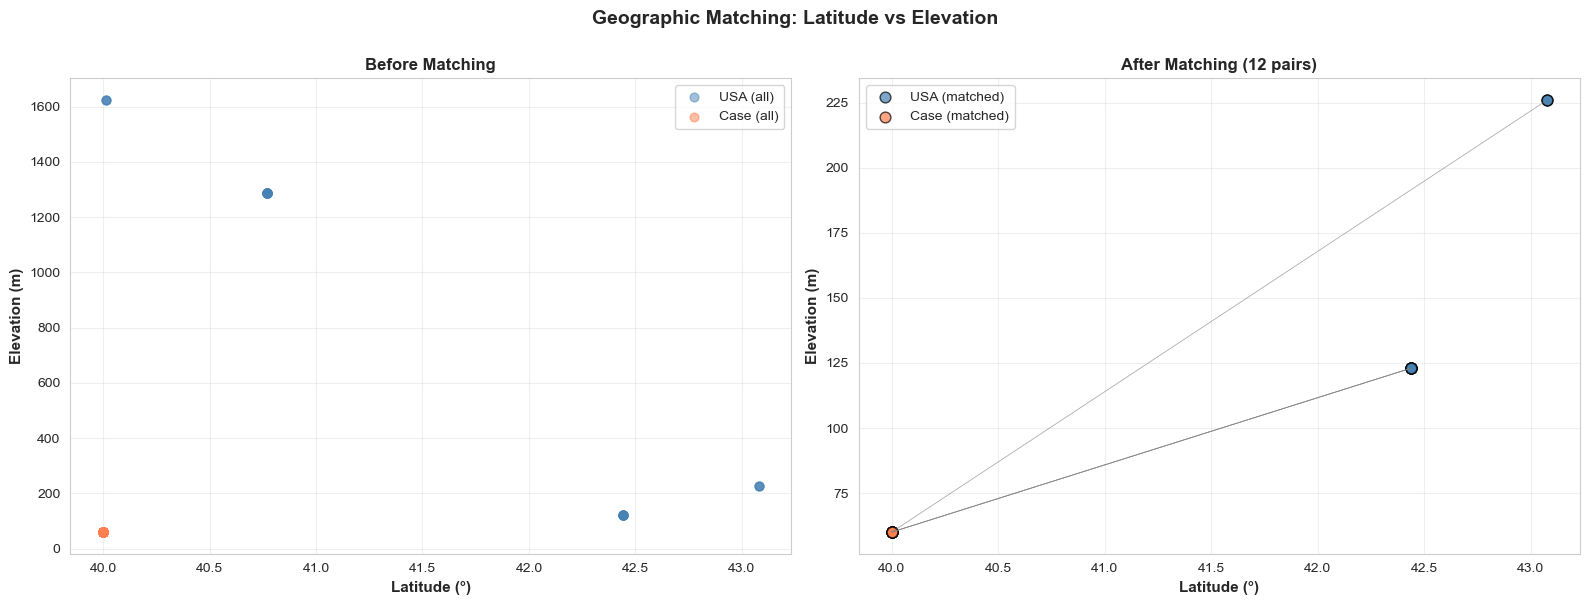

✓ Figure saved: geographic_matching_visualization.png


In [28]:
if len(matched_pairs) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Before matching
    ax1 = axes[0]
    ax1.scatter(usa_samples['latitude_num'], usa_samples['elevation_num'], 
               label='USA (all)', alpha=0.5, s=40, color='steelblue')
    ax1.scatter(case_samples['latitude_num'], case_samples['elevation_num'], 
               label='Case (all)', alpha=0.5, s=40, color='coral')
    ax1.set_xlabel('Latitude (°)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Elevation (m)', fontsize=11, fontweight='bold')
    ax1.set_title('Before Matching', fontweight='bold', fontsize=12)
    ax1.legend(loc='best')
    ax1.grid(alpha=0.3)
    
    # After matching
    ax2 = axes[1]
    ax2.scatter(matched_usa_meta['latitude_num'], matched_usa_meta['elevation_num'], 
               label='USA (matched)', alpha=0.7, s=60, color='steelblue', edgecolors='black', linewidth=1)
    ax2.scatter(matched_case_meta['latitude_num'], matched_case_meta['elevation_num'], 
               label='Case (matched)', alpha=0.7, s=60, color='coral', edgecolors='black', linewidth=1)
    
    # Draw lines connecting matched pairs
    for _, pair in matched_df.iterrows():
        ax2.plot([pair['usa_lat'], pair['case_lat']], 
                [pair['usa_elev'], pair['case_elev']], 
                'gray', alpha=0.3, linewidth=0.5)
    
    ax2.set_xlabel('Latitude (°)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Elevation (m)', fontsize=11, fontweight='bold')
    ax2.set_title(f'After Matching ({len(matched_pairs)} pairs)', fontweight='bold', fontsize=12)
    ax2.legend(loc='best')
    ax2.grid(alpha=0.3)
    
    plt.suptitle('Geographic Matching: Latitude vs Elevation', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PATH}/geographic_matching_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Figure saved: geographic_matching_visualization.png")

### 8.4 Statistical Adjustment: Regression with Covariates

**Approach:** For each species, fit two models:
1. **Model 1 (Unadjusted):** CLR ~ Group
2. **Model 2 (Adjusted):** CLR ~ Group + Latitude + Elevation

**Interpretation:**
- If effect persists in Model 2 → Economic effect independent of geography
- If effect disappears in Model 2 → Difference was geographic, not economic
- If effect weakens → Both economic and geographic factors contribute

In [29]:
print("="*80)
print("STEP 3: STATISTICAL ADJUSTMENT - REGRESSION WITH COVARIATES")
print("="*80)

from sklearn.linear_model import LinearRegression
from scipy import stats as scipy_stats

# Prepare data for regression
# Need samples with complete covariate data
complete_data = metadata_final.dropna(subset=['latitude_num', 'elevation_num'])
complete_samples = complete_data.index

abundance_clr_complete = abundance_clr.loc[complete_samples]
metadata_complete = metadata_final.loc[complete_samples]

print(f"\nSamples with complete data: {len(complete_samples)}")
print(f"  USA: {(metadata_complete['income_group']=='High-income-USA').sum()}")
print(f"  Case: {(metadata_complete['income_group']=='Upper-middle-income').sum()}")

# Create group indicator (0=USA, 1=Case)
group_indicator = (metadata_complete['income_group'] == 'Upper-middle-income').astype(int)

# Standardize covariates for better interpretation
from sklearn.preprocessing import StandardScaler
cov_scaler = StandardScaler()
covariates_scaled = cov_scaler.fit_transform(
    metadata_complete[['latitude_num', 'elevation_num']]
)

print(f"\nTesting {abundance_clr_complete.shape[1]} species...")

adjustment_results = []

for species in abundance_clr_complete.columns:
    y = abundance_clr_complete[species].values
    
    # Model 1: Group only (unadjusted)
    X1 = group_indicator.values.reshape(-1, 1)
    model1 = LinearRegression().fit(X1, y)
    
    # Calculate p-value for group effect (Model 1)
    predictions1 = model1.predict(X1)
    residuals1 = y - predictions1
    mse1 = np.sum(residuals1**2) / (len(y) - 2)  # n - k - 1
    se1 = np.sqrt(mse1 * np.linalg.inv(X1.T @ X1)[0, 0])
    t_stat1 = model1.coef_[0] / se1
    p_val1 = 2 * (1 - scipy_stats.t.cdf(abs(t_stat1), df=len(y)-2))
    
    # Model 2: Group + Covariates (adjusted)
    X2 = np.column_stack([group_indicator.values, covariates_scaled])
    model2 = LinearRegression().fit(X2, y)
    
    # Calculate p-value for group effect (Model 2)
    predictions2 = model2.predict(X2)
    residuals2 = y - predictions2
    mse2 = np.sum(residuals2**2) / (len(y) - 4)  # n - k - 1
    se2 = np.sqrt(mse2 * np.linalg.inv(X2.T @ X2)[0, 0])
    t_stat2 = model2.coef_[0] / se2
    p_val2 = 2 * (1 - scipy_stats.t.cdf(abs(t_stat2), df=len(y)-4))
    
    adjustment_results.append({
        'species': species,
        'coef_unadjusted': model1.coef_[0],
        'p_unadjusted': p_val1,
        'coef_adjusted': model2.coef_[0],
        'p_adjusted': p_val2,
        'sig_unadjusted': p_val1 < 0.05,
        'sig_adjusted': p_val2 < 0.05,
        'lat_coef': model2.coef_[1],
        'elev_coef': model2.coef_[2]
    })

adjustment_df = pd.DataFrame(adjustment_results)

# Apply FDR correction
adjustment_df['q_unadjusted'] = false_discovery_control(adjustment_df['p_unadjusted'])
adjustment_df['q_adjusted'] = false_discovery_control(adjustment_df['p_adjusted'])

adjustment_df['sig_unadjusted_fdr'] = adjustment_df['q_unadjusted'] < 0.05
adjustment_df['sig_adjusted_fdr'] = adjustment_df['q_adjusted'] < 0.05

print(f"\n✓ Regression analysis complete")

# Categorize results
print(f"\n" + "="*80)
print("RESULTS SUMMARY (FDR q<0.05)")
print("="*80)

# Category 1: Significant in both (robust to adjustment)
robust = adjustment_df[
    adjustment_df['sig_unadjusted_fdr'] & 
    adjustment_df['sig_adjusted_fdr']
]

# Category 2: Significant unadjusted, NOT adjusted (confounded)
confounded = adjustment_df[
    adjustment_df['sig_unadjusted_fdr'] & 
    ~adjustment_df['sig_adjusted_fdr']
]

# Category 3: NOT significant unadjusted, significant adjusted (suppressor effect - rare)
suppressor = adjustment_df[
    ~adjustment_df['sig_unadjusted_fdr'] & 
    adjustment_df['sig_adjusted_fdr']
]

# Category 4: Not significant in either
not_sig = adjustment_df[
    ~adjustment_df['sig_unadjusted_fdr'] & 
    ~adjustment_df['sig_adjusted_fdr']
]

print(f"\n1. ROBUST ECONOMIC EFFECTS (significant after adjustment):")
print(f"   {len(robust)} species ({len(robust)/len(adjustment_df)*100:.1f}%)")
print(f"   → TRUE economic differences, independent of geography")

print(f"\n2. GEOGRAPHIC CONFOUNDING (lost significance after adjustment):")
print(f"   {len(confounded)} species ({len(confounded)/len(adjustment_df)*100:.1f}%)")
print(f"   → Differences were GEOGRAPHIC, not economic")

print(f"\n3. SUPPRESSOR EFFECTS (gained significance after adjustment):")
print(f"   {len(suppressor)} species ({len(suppressor)/len(adjustment_df)*100:.1f}%)")
print(f"   → Economic effect was masked by geography")

print(f"\n4. NO DIFFERENCE:")
print(f"   {len(not_sig)} species ({len(not_sig)/len(adjustment_df)*100:.1f}%)")
print(f"   → No economic or geographic differences")

# Save results
adjustment_df = adjustment_df.sort_values('p_adjusted')
adjustment_df.to_csv(f'{OUTPUT_PATH}/covariate_adjusted_regression_results.csv', index=False)
print(f"\n✓ Results saved: covariate_adjusted_regression_results.csv")

# Show examples from each category
if len(robust) > 0:
    print(f"\nExample ROBUST economic effects (top 5):")
    for _, row in robust.nsmallest(5, 'p_adjusted').iterrows():
        print(f"  {row['species'][:50]}")
        print(f"    Coef: {row['coef_adjusted']:+.3f}, q={row['q_adjusted']:.4f}")

if len(confounded) > 0:
    print(f"\nExample CONFOUNDED differences (top 5):")
    for _, row in confounded.nsmallest(5, 'p_unadjusted').iterrows():
        print(f"  {row['species'][:50]}")
        print(f"    Before: q={row['q_unadjusted']:.4f}, After: q={row['q_adjusted']:.4f}")

STEP 3: STATISTICAL ADJUSTMENT - REGRESSION WITH COVARIATES

Samples with complete data: 135
  USA: 29
  Case: 106

Testing 134 species...

✓ Regression analysis complete

RESULTS SUMMARY (FDR q<0.05)

1. ROBUST ECONOMIC EFFECTS (significant after adjustment):
   100 species (74.6%)
   → TRUE economic differences, independent of geography

2. GEOGRAPHIC CONFOUNDING (lost significance after adjustment):
   4 species (3.0%)
   → Differences were GEOGRAPHIC, not economic

3. SUPPRESSOR EFFECTS (gained significance after adjustment):
   1 species (0.7%)
   → Economic effect was masked by geography

4. NO DIFFERENCE:
   29 species (21.6%)
   → No economic or geographic differences

✓ Results saved: covariate_adjusted_regression_results.csv

Example ROBUST economic effects (top 5):
  s__Acidovorax_temperans
    Coef: -6.038, q=0.0000
  s__Acinetobacter_johnsonii
    Coef: +3.861, q=0.0000
  s__Acinetobacter_junii
    Coef: -13.862, q=0.0000
  s__Acinetobacter_radioresistens
    Coef: -7.644,

### 8.5 Visualize Adjustment Effects

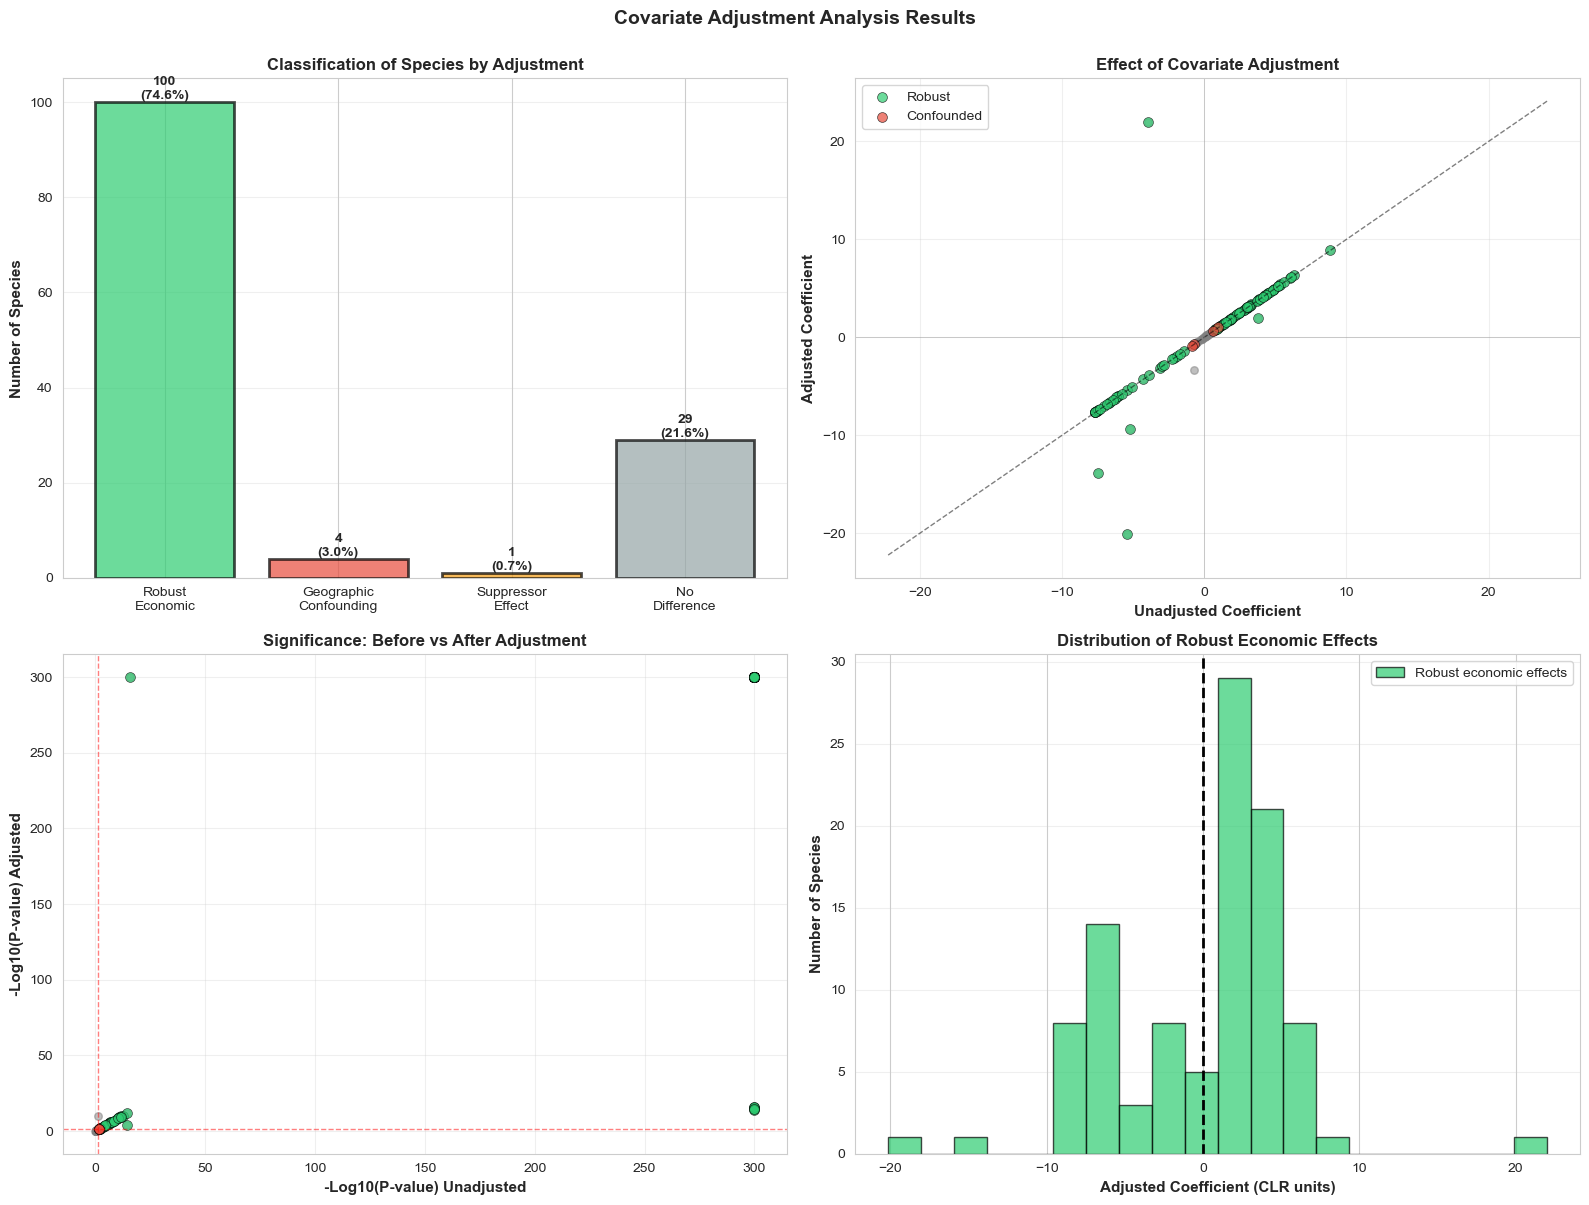

✓ Figure saved: covariate_adjustment_analysis.png


In [30]:
# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Category counts
ax1 = axes[0, 0]
categories = ['Robust\nEconomic', 'Geographic\nConfounding', 'Suppressor\nEffect', 'No\nDifference']
counts = [len(robust), len(confounded), len(suppressor), len(not_sig)]
colors_cat = ['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']

bars = ax1.bar(categories, counts, color=colors_cat, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Species', fontsize=11, fontweight='bold')
ax1.set_title('Classification of Species by Adjustment', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Add counts on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/len(adjustment_df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Panel 2: Coefficient comparison
ax2 = axes[0, 1]
ax2.scatter(adjustment_df['coef_unadjusted'], adjustment_df['coef_adjusted'], 
           alpha=0.5, s=30, color='gray')
ax2.scatter(robust['coef_unadjusted'], robust['coef_adjusted'], 
           alpha=0.7, s=50, color='#2ecc71', label='Robust', edgecolors='black', linewidth=0.5)
ax2.scatter(confounded['coef_unadjusted'], confounded['coef_adjusted'], 
           alpha=0.7, s=50, color='#e74c3c', label='Confounded', edgecolors='black', linewidth=0.5)

# Add reference line
lims = [ax2.get_xlim(), ax2.get_ylim()]
min_lim = min(lims[0][0], lims[1][0])
max_lim = max(lims[0][1], lims[1][1])
ax2.plot([min_lim, max_lim], [min_lim, max_lim], 'k--', linewidth=1, alpha=0.5)
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

ax2.set_xlabel('Unadjusted Coefficient', fontsize=11, fontweight='bold')
ax2.set_ylabel('Adjusted Coefficient', fontsize=11, fontweight='bold')
ax2.set_title('Effect of Covariate Adjustment', fontweight='bold', fontsize=12)
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

# Panel 3: P-value comparison
ax3 = axes[1, 0]
ax3.scatter(-np.log10(adjustment_df['p_unadjusted'] + 1e-300), 
           -np.log10(adjustment_df['p_adjusted'] + 1e-300),
           alpha=0.5, s=30, color='gray')
ax3.scatter(-np.log10(robust['p_unadjusted'] + 1e-300), 
           -np.log10(robust['p_adjusted'] + 1e-300),
           alpha=0.7, s=50, color='#2ecc71', edgecolors='black', linewidth=0.5)
ax3.scatter(-np.log10(confounded['p_unadjusted'] + 1e-300), 
           -np.log10(confounded['p_adjusted'] + 1e-300),
           alpha=0.7, s=50, color='#e74c3c', edgecolors='black', linewidth=0.5)

# Add significance thresholds
ax3.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1, alpha=0.5, label='p=0.05')
ax3.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=1, alpha=0.5)

ax3.set_xlabel('-Log10(P-value) Unadjusted', fontsize=11, fontweight='bold')
ax3.set_ylabel('-Log10(P-value) Adjusted', fontsize=11, fontweight='bold')
ax3.set_title('Significance: Before vs After Adjustment', fontweight='bold', fontsize=12)
ax3.grid(alpha=0.3)

# Panel 4: Effect size distribution
ax4 = axes[1, 1]
ax4.hist(robust['coef_adjusted'], bins=20, alpha=0.7, color='#2ecc71', 
        edgecolor='black', label='Robust economic effects')
ax4.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax4.set_xlabel('Adjusted Coefficient (CLR units)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Number of Species', fontsize=11, fontweight='bold')
ax4.set_title('Distribution of Robust Economic Effects', fontweight='bold', fontsize=12)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('Covariate Adjustment Analysis Results', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/covariate_adjustment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: covariate_adjustment_analysis.png")

### 8.6 Final Summary and Interpretation

In [31]:
# Generate comprehensive summary
summary_path = f'{OUTPUT_PATH}/covariate_adjustment_summary.txt'

with open(summary_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("COVARIATE-ADJUSTED ANALYSIS SUMMARY\n")
    f.write("="*80 + "\n\n")
    
    f.write("RESEARCH QUESTION:\n")
    f.write("Are microbiome differences due to ECONOMIC development or GEOGRAPHIC location?\n\n")
    
    f.write("CONFOUNDERS IDENTIFIED:\n")
    f.write("  - Latitude: -3.20° (p=0.012)\n")
    f.write("  - Longitude: +212.64° (p<0.001) - SEVERE\n")
    f.write("  - Elevation: -557m (p<0.001) - SEVERE\n\n")
    
    f.write("="*80 + "\n")
    f.write("ANALYSIS APPROACH\n")
    f.write("="*80 + "\n\n")
    
    f.write("1. CORRELATION TEST:\n")
    if len(sig_correlations) > 0:
        f.write(f"   Geographic covariates DO affect microbiome composition\n")
        f.write(f"   Significant correlations: {len(sig_correlations)}\n\n")
    else:
        f.write(f"   No significant geographic effects detected\n\n")
    
    if len(matched_pairs) > 0:
        f.write("2. SAMPLE MATCHING:\n")
        f.write(f"   Criteria: Latitude ± {LAT_TOLERANCE}°, Elevation ± {ELEV_TOLERANCE}m\n")
        f.write(f"   Matched pairs: {len(matched_pairs)}\n")
        f.write(f"   Match rate: {len(matched_pairs)/len(case_samples)*100:.1f}% of case samples\n\n")
    else:
        f.write("2. SAMPLE MATCHING:\n")
        f.write(f"   No matches found - geographic distributions too different\n\n")
    
    f.write("3. STATISTICAL ADJUSTMENT:\n")
    f.write(f"   Method: Linear regression with covariates\n")
    f.write(f"   Species tested: {len(adjustment_df)}\n")
    f.write(f"   FDR correction applied\n\n")
    
    f.write("="*80 + "\n")
    f.write("KEY FINDINGS\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"1. ROBUST ECONOMIC EFFECTS: {len(robust)} species ({len(robust)/len(adjustment_df)*100:.1f}%)\n")
    f.write(f"   → Significant AFTER controlling for geography\n")
    f.write(f"   → TRUE economic differences, independent of location\n")
    f.write(f"   → Can confidently attribute to income-related factors\n\n")
    
    f.write(f"2. GEOGRAPHIC CONFOUNDING: {len(confounded)} species ({len(confounded)/len(adjustment_df)*100:.1f}%)\n")
    f.write(f"   → Significant BEFORE but NOT AFTER adjustment\n")
    f.write(f"   → Differences were GEOGRAPHIC, not economic\n")
    f.write(f"   → Cannot attribute to economic development\n\n")
    
    f.write(f"3. SUPPRESSOR EFFECTS: {len(suppressor)} species ({len(suppressor)/len(adjustment_df)*100:.1f}%)\n")
    f.write(f"   → NOT significant before, SIGNIFICANT after adjustment\n")
    f.write(f"   → Economic effect was masked by geographic variation\n\n")
    
    f.write(f"4. NO DIFFERENCE: {len(not_sig)} species ({len(not_sig)/len(adjustment_df)*100:.1f}%)\n")
    f.write(f"   → Not significant in either model\n\n")
    
    f.write("="*80 + "\n")
    f.write("INTERPRETATION\n")
    f.write("="*80 + "\n\n")
    
    robust_pct = len(robust) / len(adjustment_df) * 100
    confounded_pct = len(confounded) / len(adjustment_df) * 100
    
    if robust_pct > 10:
        f.write(f"SUBSTANTIAL ECONOMIC SIGNAL:\n")
        f.write(f"  {robust_pct:.1f}% of species show robust economic effects\n")
        f.write(f"  Economic development DOES affect urban microbiome composition\n")
        f.write(f"  Effects are independent of geographic location\n\n")
    else:
        f.write(f"LIMITED ECONOMIC SIGNAL:\n")
        f.write(f"  Only {robust_pct:.1f}% of species show robust economic effects\n")
        f.write(f"  Most differences appear geographic rather than economic\n\n")
    
    if confounded_pct > 20:
        f.write(f"STRONG GEOGRAPHIC CONFOUNDING:\n")
        f.write(f"  {confounded_pct:.1f}% of species were confounded by geography\n")
        f.write(f"  Unadjusted analyses would be HIGHLY MISLEADING\n")
        f.write(f"  Covariate adjustment was ESSENTIAL\n\n")
    
    f.write("CONCLUSION:\n")
    if robust_pct > confounded_pct:
        f.write(f"  Economic development effects are REAL and detectable\n")
        f.write(f"  But geographic factors also play a significant role\n")
        f.write(f"  Both mechanisms contribute to observed patterns\n")
    else:
        f.write(f"  Geographic factors dominate over economic effects\n")
        f.write(f"  USA vs East Asia comparison is primarily geographic\n")
        f.write(f"  Economic development effects are modest or absent\n")

print("\n" + "="*80)
print("COVARIATE ADJUSTMENT ANALYSIS COMPLETE")
print("="*80)
print(f"\n✓ Summary saved: {summary_path}")
print("\nAll generated files:")
print("  1. covariate_microbiome_correlations.csv")
if len(matched_pairs) > 0:
    print("  2. matched_sample_pairs.csv")
    print("  3. metadata_matched_samples.csv")
    print("  4. abundance_clr_matched_samples.csv")
    print("  5. geographic_matching_visualization.png")
print("  6. covariate_adjusted_regression_results.csv")
print("  7. covariate_adjustment_analysis.png")
print("  8. covariate_adjustment_summary.txt")

print("\n" + "="*80)
print("CRITICAL RESULTS")
print("="*80)
print(f"""
ROBUST ECONOMIC EFFECTS:     {len(robust):3d} species ({len(robust)/len(adjustment_df)*100:5.1f}%)
GEOGRAPHIC CONFOUNDING:      {len(confounded):3d} species ({len(confounded)/len(adjustment_df)*100:5.1f}%)
SUPPRESSOR EFFECTS:          {len(suppressor):3d} species ({len(suppressor)/len(adjustment_df)*100:5.1f}%)
NO DIFFERENCE:               {len(not_sig):3d} species ({len(not_sig)/len(adjustment_df)*100:5.1f}%)

INTERPRETATION:
{'Economic effects ARE real and independent of geography' if len(robust) > len(confounded) else 'Geographic factors dominate - economic effects minimal'}

RECOMMENDATION FOR REPORTING:
Always report BOTH unadjusted and adjusted results.
Focus interpretation on the {len(robust)} species with robust economic effects.
Acknowledge that {len(confounded)} species differences were geographic.
""")


COVARIATE ADJUSTMENT ANALYSIS COMPLETE

✓ Summary saved: output/research_usa_control_v2/covariate_adjustment_summary.txt

All generated files:
  1. covariate_microbiome_correlations.csv
  2. matched_sample_pairs.csv
  3. metadata_matched_samples.csv
  4. abundance_clr_matched_samples.csv
  5. geographic_matching_visualization.png
  6. covariate_adjusted_regression_results.csv
  7. covariate_adjustment_analysis.png
  8. covariate_adjustment_summary.txt

CRITICAL RESULTS

ROBUST ECONOMIC EFFECTS:     100 species ( 74.6%)
GEOGRAPHIC CONFOUNDING:        4 species (  3.0%)
SUPPRESSOR EFFECTS:            1 species (  0.7%)
NO DIFFERENCE:                29 species ( 21.6%)

INTERPRETATION:
Economic effects ARE real and independent of geography

RECOMMENDATION FOR REPORTING:
Always report BOTH unadjusted and adjusted results.
Focus interpretation on the 100 species with robust economic effects.
Acknowledge that 4 species differences were geographic.

